In [9]:
!pip install transformers accelerate pandas matplotlib scipy

In [10]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy import stats

In [11]:
print("Versão do PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))
else:
    print("Nenhuma GPU disponível. O teste será feito apenas em CPU.")

Versão do PyTorch: 2.11.0+cu128
GPU disponível: True
Nome da GPU: Tesla T4


In [12]:
MODEL_NAME = "distilgpt2"

prompts = [
    "Artificial intelligence is changing the technology market because",
    "High performance computing allows generative AI models to",
    "The future of computer hardware will be influenced by",
    "Machine learning models require large amounts of data because",
    "Cloud computing and GPUs are important for AI because",
    "Generative AI can impact jobs by",
    "The demand for graphics cards increased because",
    "Training large language models requires",
    "Data centers are becoming more important because",
    "The relationship between AI and hardware is"
]

MAX_NEW_TOKENS = 50
REPETITIONS = 10

In [13]:
def run_benchmark(device_name):
    device = torch.device(device_name)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
    model.to(device)
    model.eval()

    results = []

    for _ in range(2):
        inputs = tokenizer(prompts[0], return_tensors="pt").to(device)
        with torch.no_grad():
            _ = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

    if device_name == "cuda":
        torch.cuda.synchronize()

    for prompt_id, prompt in enumerate(prompts):
        for repetition in range(REPETITIONS):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)

            if device_name == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )

            if device_name == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            elapsed_time = end_time - start_time
            input_tokens = inputs["input_ids"].shape[1]
            output_tokens = output.shape[1]
            generated_tokens = output_tokens - input_tokens
            tokens_per_second = generated_tokens / elapsed_time

            results.append({
                "device": device_name,
                "prompt_id": prompt_id,
                "repetition": repetition + 1,
                "elapsed_time_seconds": elapsed_time,
                "generated_tokens": generated_tokens,
                "tokens_per_second": tokens_per_second
            })

    del model
    del tokenizer

    if device_name == "cuda":
        torch.cuda.empty_cache()

    return results

In [14]:
import torch
import pandas as pd

all_results = []

print("Executando teste em CPU...")
cpu_results = run_benchmark("cpu")
all_results.extend(cpu_results)

if torch.cuda.is_available():
    print("Executando teste em GPU...")
    gpu_results = run_benchmark("cuda")
    all_results.extend(gpu_results)
else:
    print("GPU não disponível. Apenas resultados de CPU foram coletados.")

df = pd.DataFrame(all_results)
df.head()

Executando teste em CPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Executando teste em GPU...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

,device,prompt_id,repetition,elapsed_time_seconds,generated_tokens,tokens_per_second
0,cpu,0,1,5.265811,50,9.495213
1,cpu,0,2,3.856218,50,12.966071
2,cpu,0,3,3.348741,50,14.930985
3,cpu,0,4,4.752071,50,10.521728
4,cpu,0,5,3.646334,50,13.712404


In [15]:
def confidence_interval_95(values):
    values = pd.Series(values)
    n = len(values)
    mean = values.mean()
    std = values.std()

    if n <= 1:
        return 0

    error = stats.t.ppf(0.975, n - 1) * std / (n ** 0.5)
    return error

summary = df.groupby("device").agg(
    mean_time=("elapsed_time_seconds", "mean"),
    std_time=("elapsed_time_seconds", "std"),
    ci95_time=("elapsed_time_seconds", confidence_interval_95),
    mean_tokens_per_second=("tokens_per_second", "mean"),
    std_tokens_per_second=("tokens_per_second", "std"),
    ci95_tokens_per_second=("tokens_per_second", confidence_interval_95),
    executions=("elapsed_time_seconds", "count")
).reset_index()

summary

,device,mean_time,std_time,ci95_time,mean_tokens_per_second,std_tokens_per_second,ci95_tokens_per_second,executions
0,cpu,1.91282,1.048429,0.208031,26.703764,5.844469,1.159669,100
1,cuda,0.25285,0.076811,0.015241,184.171859,18.052418,3.581991,100


In [16]:
if "cuda" in summary["device"].values:
    cpu_time = summary.loc[summary["device"] == "cpu", "mean_time"].values[0]
    gpu_time = summary.loc[summary["device"] == "cuda", "mean_time"].values[0]

    cpu_tps = summary.loc[summary["device"] == "cpu", "mean_tokens_per_second"].values[0]
    gpu_tps = summary.loc[summary["device"] == "cuda", "mean_tokens_per_second"].values[0]

    speedup_time = cpu_time / gpu_time
    speedup_tps = gpu_tps / cpu_tps

    print(f"Ganho baseado no tempo médio: {speedup_time:.2f}x")
    print(f"Ganho baseado em tokens por segundo: {speedup_tps:.2f}x")
else:
    print("Sem GPU disponível para calcular ganho.")

Ganho baseado no tempo médio: 7.57x
Ganho baseado em tokens por segundo: 6.90x


In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.47
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.5Gi       6.6Gi       2.0Mi       3.6Gi       9.9Gi
Swap:             0B          0B          0B


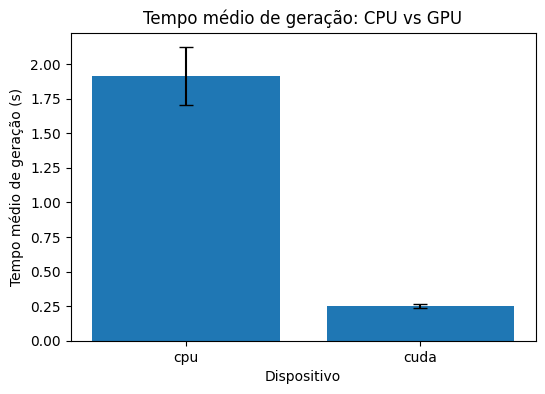

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(summary["device"], summary["mean_time"], yerr=summary["ci95_time"], capsize=5)
plt.xlabel("Dispositivo")
plt.ylabel("Tempo médio de geração (s)")
plt.title("Tempo médio de geração: CPU vs GPU")
plt.savefig("grafico_tempo_cpu_gpu.png", dpi=300, bbox_inches="tight")
plt.show()

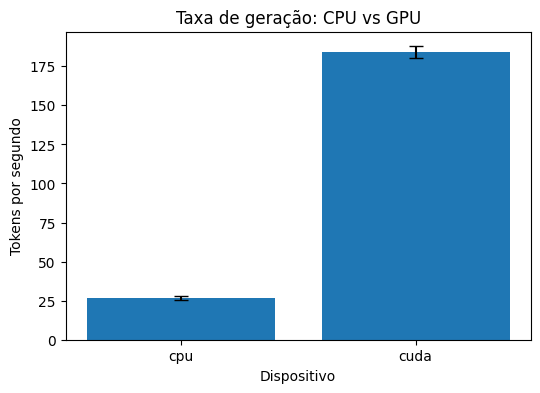

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(summary["device"], summary["mean_tokens_per_second"], yerr=summary["ci95_tokens_per_second"], capsize=5)
plt.xlabel("Dispositivo")
plt.ylabel("Tokens por segundo")
plt.title("Taxa de geração: CPU vs GPU")
plt.savefig("grafico_tokens_cpu_gpu.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
df.to_csv("resultados_benchmark.csv", index=False)
summary.to_csv("resumo_benchmark.csv", index=False)

print("Arquivos salvos:")
print("resultados_benchmark.csv")
print("resumo_benchmark.csv")
print("grafico_tempo_cpu_gpu.png")
print("grafico_tokens_cpu_gpu.png")

Arquivos salvos:
resultados_benchmark.csv
resumo_benchmark.csv
grafico_tempo_cpu_gpu.png
grafico_tokens_cpu_gpu.png
